In [24]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

In [27]:
from dataset_pipeline import DatasetPipeline
from dataloader_factory import DataLoaderFactory

from utils import (
    tune_optimizers_with_optuna,
    print_hyperparams_table
)

## Hyperparameters

In [14]:
batch_size = 32
num_epochs = 2
learning_rate = 5e-5
num_labels = 2
max_length = 512
seed = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset

In [ ]:
train_size = 2000
test_size = 250
val_size = 250
seed = 42

tokenizer_name = "distilbert-base-uncased"

In [16]:
pipeline = DatasetPipeline(seed=seed)
train_ds, val_ds, test_ds = pipeline.prepare_nlp(
    csv_path="content/IMDB_Dataset.csv",
    tokenizer_name=tokenizer_name,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
)

Map: 100%|██████████| 250/250 [00:00<00:00, 400.92 examples/s]


In [18]:
loader_factory = DataLoaderFactory(task_type="nlp", batch_size=16)
train_loader, val_loader, test_loader = loader_factory.create_loaders(train_ds, val_ds, test_ds)

## Optuna

In [19]:
optimizers = ["AdamW"]
best_params = tune_optimizers_with_optuna(optimizers, 
                                          n_trials=1,
                                          train_dataset=train_ds,
                                          val_dataset=val_ds,
                                          num_classes=num_labels,
                                          task_type="nlp",
                                          model_fn=lambda num_classes: DistilBertForSequenceClassification.from_pretrained(
                                              "distilbert-base-uncased", num_labels=num_classes
                                          ))

print("\n📋 Podsumowanie:")
for opt, params in best_params.items():
    print(f"{opt}: {params}")

[I 2025-05-18 13:11:47,056] A new study created in memory with name: no-name-e0749eb8-f739-4b94-b1f1-12e6640a2e84



🔍 Strojenie hiperparametrów dla: AdamW


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2025-05-18 13:12:16,253] Trial 0 finished with value: 0.888 and parameters: {'learning_rate': 3.26580722728647e-05, 'batch_size': 8, 'num_epochs': 1}. Best is trial 0 with value: 0.888.


✅ Najlepsze hiperparametry dla AdamW: {'learning_rate': 3.26580722728647e-05, 'batch_size': 8, 'num_epochs': 1}

📋 Podsumowanie:
AdamW: {'params': {'learning_rate': 3.26580722728647e-05, 'batch_size': 8, 'num_epochs': 1}, 'accuracy': 0.888}


In [20]:
print_hyperparams_table(best_params)

╒═════════════╤═════════════════╤═══════════════════════════════════════════════════════════════════════════╕
│ Optimizer   │   Best Accuracy │ Best Hyperparameters                                                      │
╞═════════════╪═════════════════╪═══════════════════════════════════════════════════════════════════════════╡
│ AdamW       │           0.888 │ {'learning_rate': 3.26580722728647e-05, 'batch_size': 8, 'num_epochs': 1} │
╘═════════════╧═════════════════╧═══════════════════════════════════════════════════════════════════════════╛


## Training

In [21]:
from train_compare import compare_optimizers_with_metrics

In [22]:
import neptune

run = neptune.init_run(
    project="notatkipw/ZZSN",
    api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIyMzQ0ZWY0Zi0wZmZhLTRjZGItODRlNS02YWE5NmY5Yjc3OWIifQ==",            # Replace with your Neptune API token
)

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/notatkipw/ZZSN/e/ZZSN-38


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


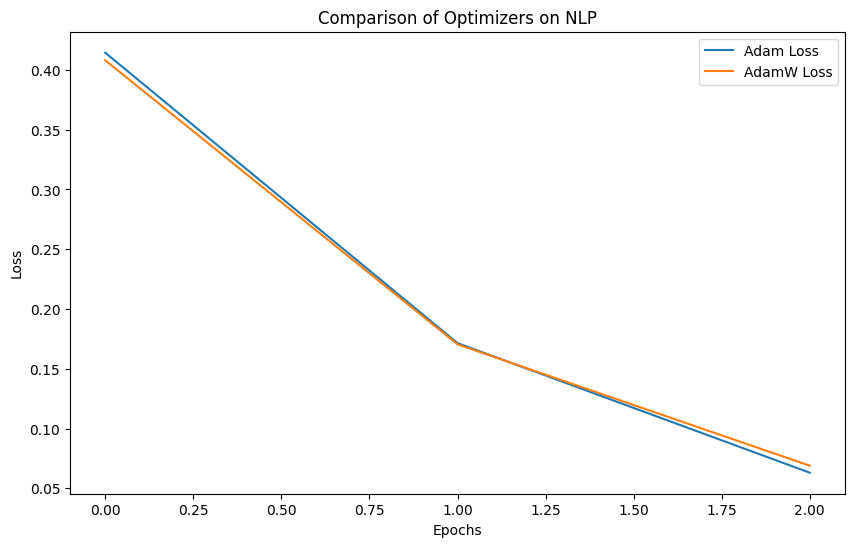

Optimizer: Adam
Accuracy: 0.8920
Precision: 0.8940
Recall: 0.8920
F1 Score: 0.8919
------------------------------
Optimizer: AdamW
Accuracy: 0.9080
Precision: 0.9080
Recall: 0.9080
F1 Score: 0.9080
------------------------------
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 5 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 5 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/notatkipw/ZZSN/e/ZZSN-38/metadata


In [23]:
# optimizers = ["ADOPT", "SGD", "Adam", "AdamW", "RMSprop"]
optimizers = {
    "Adam": {"lr": 0.00005},
    "AdamW": {"lr": 2e-5, "weight_decay": 0.01}
}

compare_optimizers_with_metrics(
    optimizers=optimizers, 
    run=run,
    model_fn=lambda num_classes: DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=num_classes),
    train_loader=train_loader,
    test_loader=test_loader,
    task_type="nlp",
    num_classes=2,
    epochs=3,
    device=device
)

run.stop()